<a href="https://colab.research.google.com/github/Loopinlogix/AI_Fairness/blob/main/Ai_Fairness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Fairness ML Assignment - Lesson 14
Crystal MacNeil

In [2]:
# Github

# Clone a public GitHub repository
!git clone https://github.com/Loopinlogix/AI_Fairness.git

# Change directory into the cloned repository
%cd AI_Fairness

# List the contents of the directory
!ls

Cloning into 'AI_Fairness'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/AI_Fairness
README.md


TASK 1: DATASET PREPARATION
TASK 2: MODEL TRAINING AND EVALUATION
Accuracy: 0.8903
ROC AUC: 0.9650

Confusion Matrix:
 [[1636  171]
 [ 487 3706]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.91      0.83      1807
           1       0.96      0.88      0.92      4193

    accuracy                           0.89      6000
   macro avg       0.86      0.89      0.88      6000
weighted avg       0.90      0.89      0.89      6000

TASK 3: FAIRNESS EVALUATION
     Education  Accuracy  Precision    Recall        F1  Selection_Rate  \
0          PhD  0.919463   0.979296  0.925636  0.951710        0.810403   
1    Bachelors  0.884346   0.956468  0.865225  0.908561        0.600737   
2      Masters  0.897608   0.957823  0.902564  0.929373        0.703349   
3  High School  0.863105   0.904437  0.830721  0.866013        0.489149   

        TPR       FPR  
0  0.925636  0.117647  
1  0.865225  0.077851  
2  0.902564  0.116981  
3 


SHAP Global Summary Plot (using full background data):


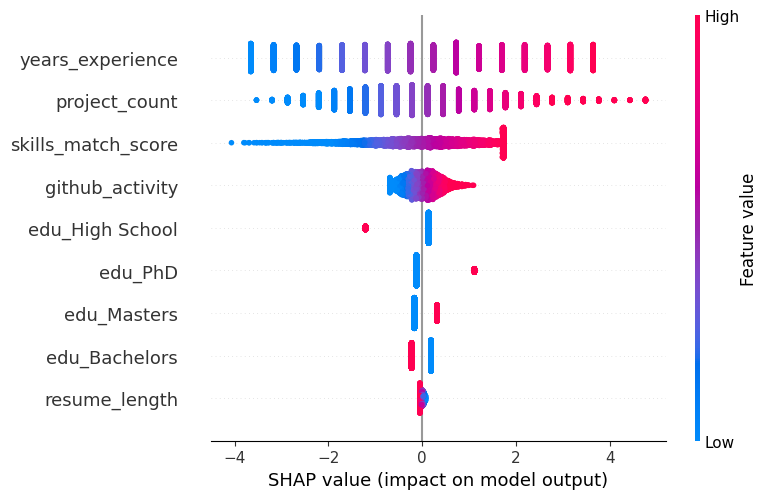

TASK 8: SHAP LOCAL WATERFALL PLOT)

SHAP Waterfall Plot for Instance 0:


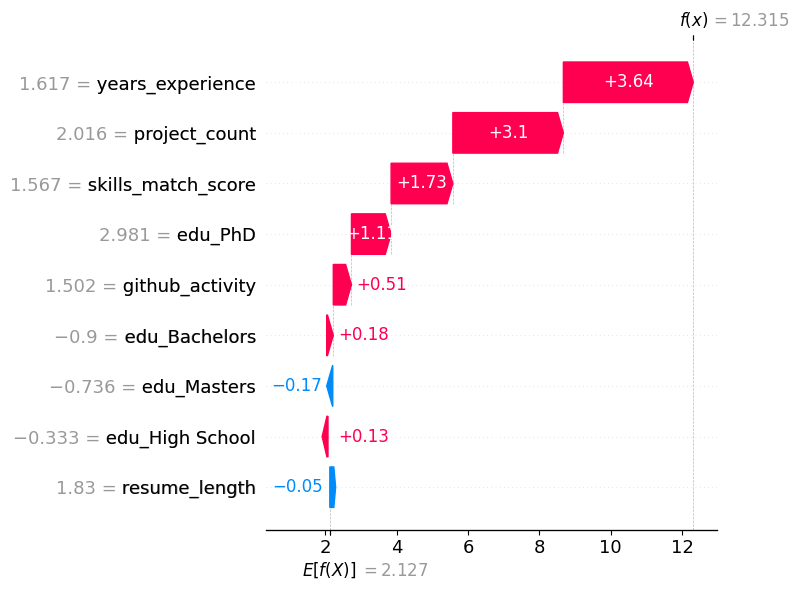

TASK 9: SHAP VS LIME FEATURE IMPORTANCE COMPARISON (DATA PREP)


,Feature,SHAP,LIME
8,years_experience,3.641616,0.308562
5,project_count,3.098182,0.255070
7,skills_match_score,1.730732,0.188454
3,edu_PhD,1.111183,0.100104
4,github_activity,0.509118,0.056143
1,edu_High School,0.134087,0.114525
0,edu_Bachelors,0.184838,0.000000
2,edu_Masters,-0.170194,0.000000
6,resume_length,-0.051236,0.000000


TASK 10: SHAP VS LIME FEATURE IMPORTANCE COMPARISON (VISUALIZATION)


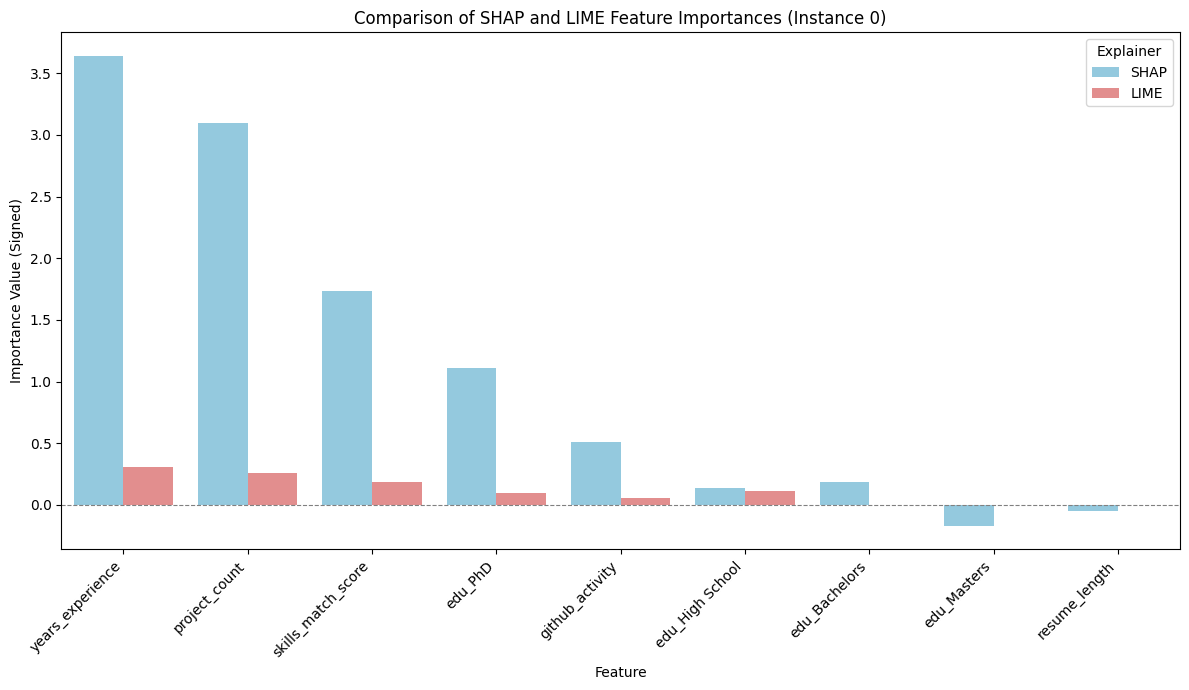

In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import lime
from lime.lime_tabular import LimeTabularExplainer
import shap
import matplotlib.pyplot as plt
import seaborn as sns


print("=" * 60)
print("TASK 1: DATASET PREPARATION")
print("=" * 60)
# Load dataset
df = pd.read_csv('/content/ai_resume_screening.csv')

# Encode target
le_target = LabelEncoder()
df['shortlisted'] = le_target.fit_transform(df['shortlisted'])  # Yes=1, No=0

# One-hot encode education level (sensitive attribute for fairness)
df_encoded = pd.get_dummies(df, columns=['education_level'], prefix='edu')

# Define features and target
feature_cols = ['years_experience', 'skills_match_score', 'project_count',
                'resume_length', 'github_activity',
                'edu_Bachelors', 'edu_High School', 'edu_Masters', 'edu_PhD']
X = df_encoded[feature_cols]
y = df_encoded['shortlisted']

# Sensitive attribute for fairness analysis
sensitive_attr = df['education_level']  # Original categorical

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
sensitive_train, sensitive_test = train_test_split(
    sensitive_attr, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("TASK 2: MODEL TRAINING AND EVALUATION")
print("=" * 60)

# Train model
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("=" * 60)
print("TASK 3: FAIRNESS EVALUATION")
print("=" * 60)

def selection_rate(y_true, y_pred): return np.mean(y_pred)
def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0
def true_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

# Compute metrics by education group
groups = sensitive_test.unique()
results = []
for group in groups:
    mask = sensitive_test == group
    y_true_g, y_pred_g = y_test[mask], y_pred[mask]
    tn, fp, fn, tp = confusion_matrix(y_true_g, y_pred_g).ravel()
    results.append({
        'Education': group,
        'Accuracy': accuracy_score(y_true_g, y_pred_g),
        'Precision': precision_score(y_true_g, y_pred_g),
        'Recall': recall_score(y_true_g, y_pred_g),
        'F1': f1_score(y_true_g, y_pred_g),
        'Selection_Rate': selection_rate(y_true_g, y_pred_g),
        'TPR': true_positive_rate(y_true_g, y_pred_g),
        'FPR': false_positive_rate(y_true_g, y_pred_g)
    })

fairness_df = pd.DataFrame(results)
print(fairness_df)

print("=" * 60)
print("TASK 4: FAIRNESS METRICS WITH METRICFRAME")
print("=" * 60)

# Define the metrics to be used with MetricFrame
# Reusing custom functions for selection_rate, false_positive_rate, true_positive_rate
fairness_metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1_score': f1_score,
    'selection_rate': selection_rate, # Custom function
    'tpr': true_positive_rate, # Custom function
    'fpr': false_positive_rate # Custom function
}

# Create a MetricFrame
# Note: model.predict_proba is for probability-based metrics if needed, here using y_pred
metric_frame = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test
)

print("Fairness Metrics using MetricFrame:")
print(metric_frame.by_group)


print("=" * 60)
print("TASK 5: SHAP LOCAL EXPLAINABILITY (MANUAL)")
print("=" * 60)

# Manual SHAP value calculation for instance i
def explain_instance(i, X_test_scaled, model, feature_names):
    # For linear model: SHAP value = coefficient * feature_value
    shap_values_instance = model.coef_[0] * X_test_scaled[i]
    base_value = model.intercept_[0]  # log-odds baseline

    # Convert to probability space
    prediction = model.predict_proba(X_test_scaled[i:i+1])[0, 1]

    print(f"Instance {i}: Predicted probability = {prediction:.4f}")
    print(f"Base value (log-odds): {base_value:.4f}")
    print("\nFeature contributions (SHAP values):")
    for name, val in zip(feature_names, shap_values_instance):
        print(f"  {name:25s}: {val:+.4f}")

    return shap_values_instance, base_value

# Explain first test instance
shap_vals, base = explain_instance(0, X_test_scaled, model, X.columns.tolist())

print("=" * 60)
print("TASK 6: LIME EXPLAINABILITY")
print("=" * 60)

# Create LIME explainer
explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=['Not Shortlisted', 'Shortlisted'],
    discretize_continuous=True,
    mode='classification'
)

# Explain a single prediction
idx = 0  # First test instance
exp = explainer.explain_instance(
    X_test_scaled[idx],
    model.predict_proba,
    num_features=6
)

# Show explanation
print(f"Prediction: {'Shortlisted' if y_pred[idx] == 1 else 'Not Shortlisted'}")
print(f"Actual: {'Shortlisted' if y_test.iloc[idx] == 1 else 'Not Shortlisted'}")
print("\nLIME Explanation (top 6 features):")
for feature, weight in exp.as_list():
    print(f"  {feature:40s}: {weight:+.4f}")

# Save visualization
exp.save_to_file('/content/lime_explanation.html')

print("=" * 60)
print("TASK 7: SHAP PLOT")
print("=" * 60)

# Initialize JS for SHAP plots
shap.initjs()

# Create a masker with max_samples set to the full size of the training data
# This addresses the previous warning about subsampling.
masker = shap.maskers.Independent(data=X_train_scaled, max_samples=X_train_scaled.shape[0])

# Create a SHAP explainer for the Logistic Regression model using the custom masker
explainer = shap.LinearExplainer(model, masker=masker)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

# Generate a SHAP summary plot
print("\nSHAP Global Summary Plot (using full background data):")
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist(), show=False)
plt.tight_layout()
plt.show()

print("=" * 60)
print("TASK 8: SHAP LOCAL WATERFALL PLOT)")
print("=" * 60)

# Select an instance to explain (e.g., the first instance in the test set)
instance_idx = 0

# Get SHAP values for the selected instance
shap_values_instance = explainer.shap_values(X_test_scaled[instance_idx])

# Get the expected value (base value) from the explainer
expected_value = explainer.expected_value

# Create a SHAP waterfall plot for the instance
print(f"\nSHAP Waterfall Plot for Instance {instance_idx}:")
shap.plots.waterfall(shap.Explanation(
    values=shap_values_instance,
    base_values=expected_value,
    data=X_test_scaled[instance_idx],
    feature_names=X.columns.tolist()
), show=False)
plt.tight_layout()
plt.show()

print("=" * 60)
print("TASK 9: SHAP VS LIME FEATURE IMPORTANCE COMPARISON (DATA PREP)")
print("=" * 60)

import pandas as pd
import numpy as np

# Extract SHAP values
# shap_values_instance and X.columns were already created in previous cells
shap_df = pd.DataFrame({
    'Feature': X.columns.tolist(),
    'SHAP': shap_values_instance
})

# Extract LIME values
lime_data = []
# exp was created in a previous cell (ceDYG2o82M3X)
for lime_feature_str, weight in exp.as_list():
    cleaned_feature_name = None
    for col_name in X.columns.tolist():
        # Check if the column name is a substring of the LIME feature string
        if col_name in lime_feature_str:
            cleaned_feature_name = col_name
            break
    if cleaned_feature_name:
        lime_data.append({'Feature': cleaned_feature_name, 'LIME': weight})
    else:
        # Fallback if no direct match, take the first part of the string
        lime_data.append({'Feature': lime_feature_str.split(' ')[0], 'LIME': weight})

lime_df = pd.DataFrame(lime_data)

# Merge dataframes on common features
# Use 'outer' merge to keep all features from both, then fill NaNs if a feature is missing in one explainer
comparison_df = pd.merge(shap_df, lime_df, on='Feature', how='outer').fillna(0)

# Sort by the absolute sum of SHAP and LIME for better visualization
comparison_df['Abs_Sum'] = np.abs(comparison_df['SHAP']) + np.abs(comparison_df['LIME'])
comparison_df = comparison_df.sort_values(by='Abs_Sum', ascending=False).drop(columns=['Abs_Sum'])

display(comparison_df)

print("=" * 60)
print("TASK 10: SHAP VS LIME FEATURE IMPORTANCE COMPARISON (VISUALIZATION)")
print("=" * 60)

# Melt the DataFrame for plotting
df_melted = comparison_df.melt(id_vars='Feature', var_name='Explainer', value_name='Importance')

fig = plt.figure(figsize=(12, 7))
sns.barplot(x='Feature', y='Importance', hue='Explainer', data=df_melted, palette={'SHAP': 'skyblue', 'LIME': 'lightcoral'})
plt.title('Comparison of SHAP and LIME Feature Importances (Instance 0)')
plt.xlabel('Feature')
plt.ylabel('Importance Value (Signed)')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a horizontal line at y=0
plt.tight_layout()
plt.show()


### Visualizing Fairness Metrics from MetricFrame

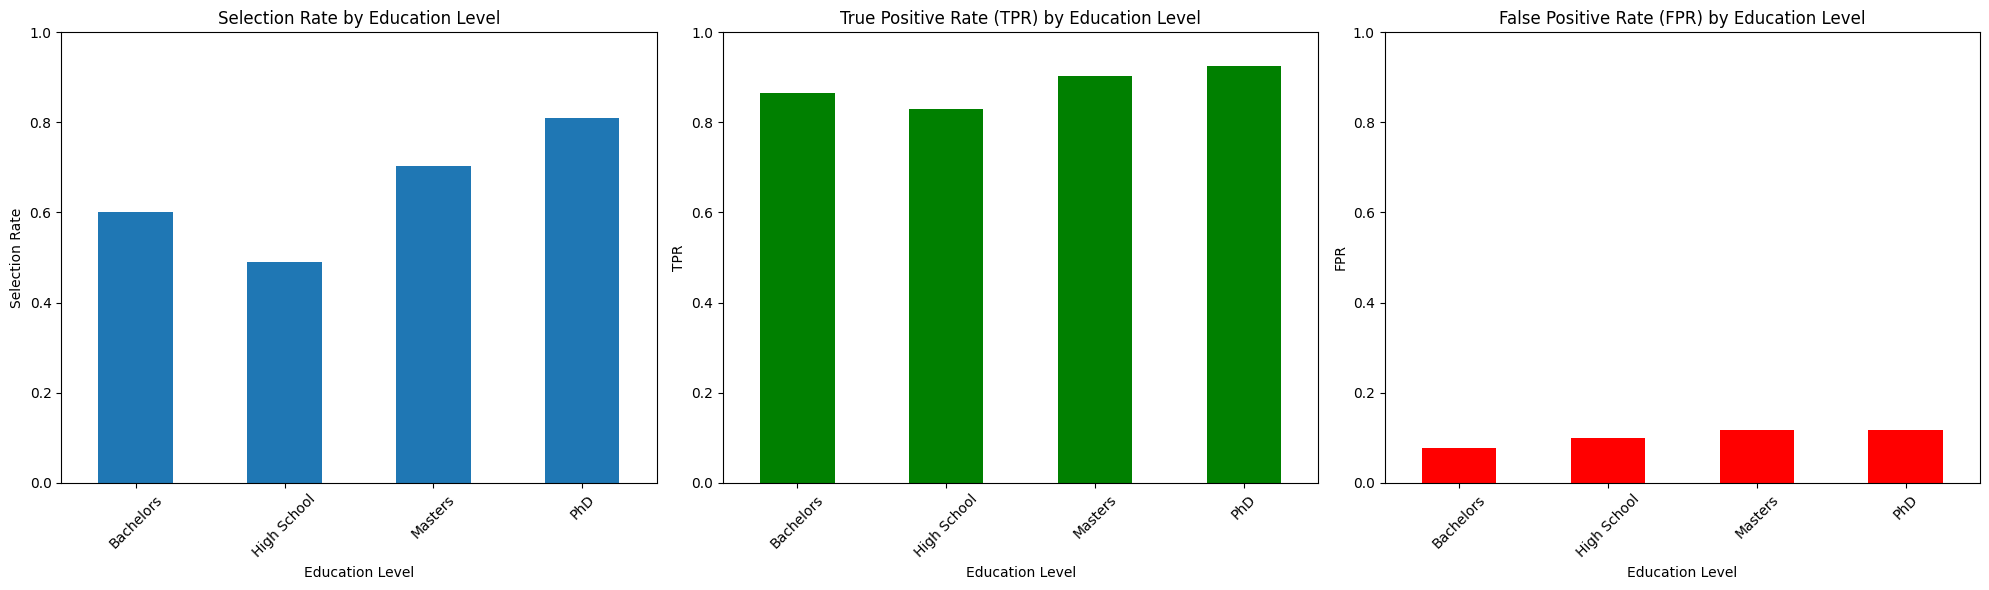

In [40]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Plotting Selection Rate
metric_frame.by_group['selection_rate'].plot.bar(ax=ax[0], title='Selection Rate by Education Level',
                                                  ylabel='Selection Rate', xlabel='Education Level')
ax[0].set_ylim(0, 1)
ax[0].tick_params(axis='x', rotation=45)

# Plotting True Positive Rate (TPR)
metric_frame.by_group['tpr'].plot.bar(ax=ax[1], title='True Positive Rate (TPR) by Education Level',
                                      ylabel='TPR', xlabel='Education Level', color='green')
ax[1].set_ylim(0, 1)
ax[1].tick_params(axis='x', rotation=45)

# Plotting False Positive Rate (FPR)
metric_frame.by_group['fpr'].plot.bar(ax=ax[2], title='False Positive Rate (FPR) by Education Level',
                                      ylabel='FPR', xlabel='Education Level', color='red')
ax[2].set_ylim(0, 1)
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Disparity in Selection Rates

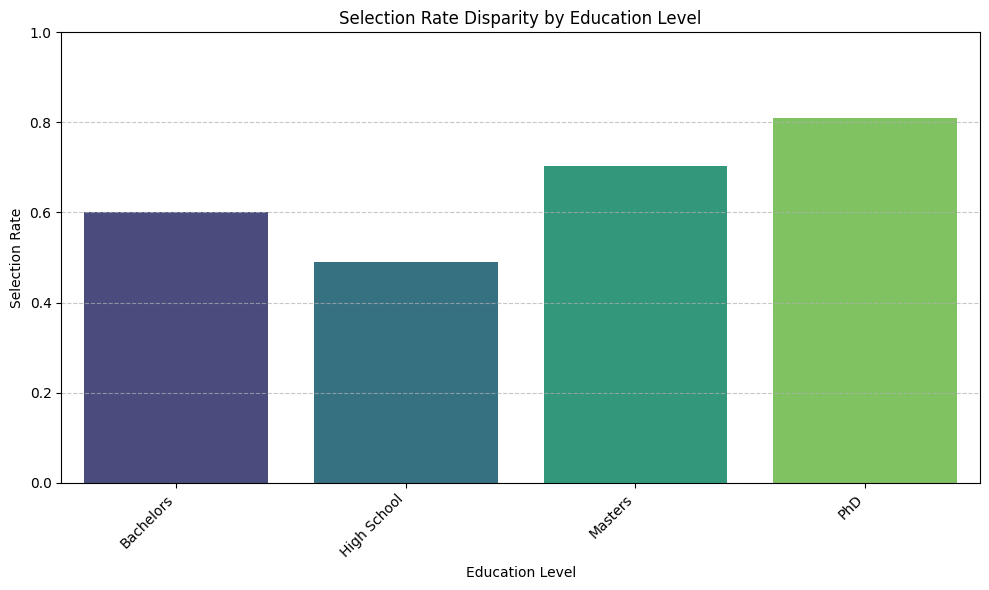

Interpretation: This plot clearly shows the differences in how frequently candidates from each education level are 'shortlisted' by the model. A higher bar indicates a higher selection rate for that group, highlighting potential disparities.


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=metric_frame.by_group.index, y=metric_frame.by_group['selection_rate'], hue=metric_frame.by_group.index, palette='viridis', legend=False)
plt.title('Selection Rate Disparity by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Selection Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation: This plot clearly shows the differences in how frequently candidates from each education level are 'shortlisted' by the model. A higher bar indicates a higher selection rate for that group, highlighting potential disparities.")

### True Positive Rate (TPR) Disparity

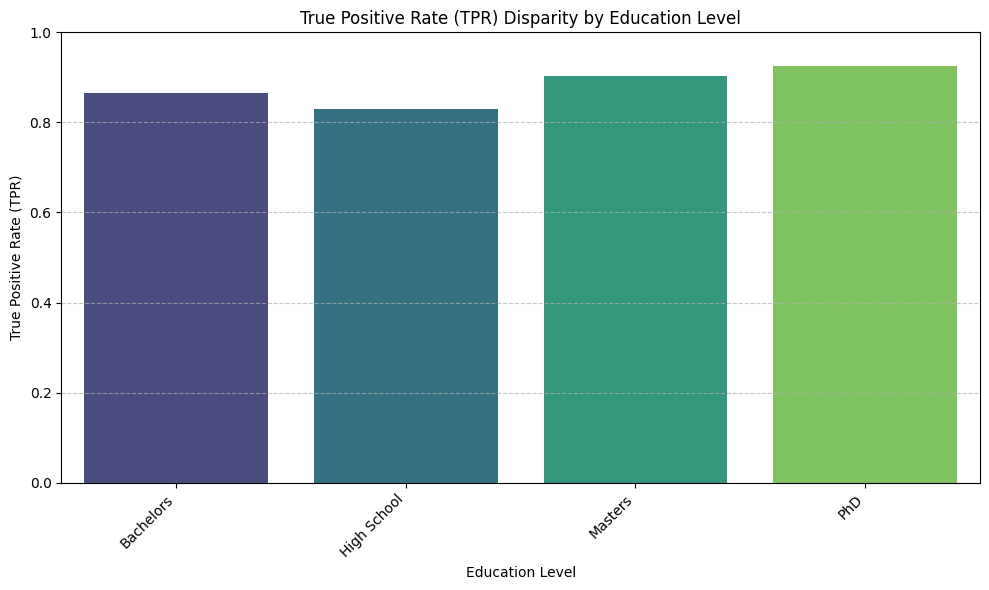

Interpretation: This plot shows how effectively the model identifies 'shortlisted' candidates within each education level. A higher bar indicates a higher TPR for that group.


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=metric_frame.by_group.index, y=metric_frame.by_group['tpr'], hue=metric_frame.by_group.index, palette='viridis', legend=False)
plt.title('True Positive Rate (TPR) Disparity by Education Level')
plt.xlabel('Education Level')
plt.ylabel('True Positive Rate (TPR)')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation: This plot shows how effectively the model identifies 'shortlisted' candidates within each education level. A higher bar indicates a higher TPR for that group.")